## Stock Sentiment Analysis using News Headlines

In [228]:
import pandas as pd

In [229]:
df=pd.read_csv('Data.csv', encoding = "ISO-8859-1")

In [230]:
df.head()

,Date,Label,Top1,Top2,Top3,Top4,Top5,Top6,Top7,Top8,...,Top16,Top17,Top18,Top19,Top20,Top21,Top22,Top23,Top24,Top25
0,2000-01-03,0,A 'hindrance to operations': extracts from the...,Scorecard,Hughes' instant hit buoys Blues,Jack gets his skates on at ice-cold Alex,Chaos as Maracana builds up for United,Depleted Leicester prevail as Elliott spoils E...,Hungry Spurs sense rich pickings,Gunners so wide of an easy target,...,Flintoff injury piles on woe for England,Hunters threaten Jospin with new battle of the...,Kohl's successor drawn into scandal,The difference between men and women,"Sara Denver, nurse turned solicitor",Diana's landmine crusade put Tories in a panic,Yeltsin's resignation caught opposition flat-f...,Russian roulette,Sold out,Recovering a title
1,2000-01-04,0,Scorecard,The best lake scene,Leader: German sleaze inquiry,"Cheerio, boyo",The main recommendations,Has Cubie killed fees?,Has Cubie killed fees?,Has Cubie killed fees?,...,On the critical list,The timing of their lives,Dear doctor,Irish court halts IRA man's extradition to Nor...,Burundi peace initiative fades after rebels re...,PE points the way forward to the ECB,Campaigners keep up pressure on Nazi war crime...,Jane Ratcliffe,Yet more things you wouldn't know without the ...,Millennium bug fails to bite
2,2000-01-05,0,Coventry caught on counter by Flo,United's rivals on the road to Rio,Thatcher issues defence before trial by video,Police help Smith lay down the law at Everton,Tale of Trautmann bears two more retellings,England on the rack,Pakistan retaliate with call for video of Walsh,Cullinan continues his Cape monopoly,...,South Melbourne (Australia),Necaxa (Mexico),Real Madrid (Spain),Raja Casablanca (Morocco),Corinthians (Brazil),Tony's pet project,Al Nassr (Saudi Arabia),Ideal Holmes show,Pinochet leaves hospital after tests,Useful links
3,2000-01-06,1,Pilgrim knows how to progress,Thatcher facing ban,McIlroy calls for Irish fighting spirit,Leicester bin stadium blueprint,United braced for Mexican wave,"Auntie back in fashion, even if the dress look...",Shoaib appeal goes to the top,Hussain hurt by 'shambles' but lays blame on e...,...,Putin admits Yeltsin quit to give him a head s...,BBC worst hit as digital TV begins to bite,How much can you pay for...,Christmas glitches,"Upending a table, Chopping a line and Scoring ...","Scientific evidence 'unreliable', defence claims",Fusco wins judicial review in extradition case,Rebels thwart Russian advance,Blair orders shake-up of failing NHS,Lessons of law's hard heart
4,2000-01-07,1,Hitches and Horlocks,Beckham off but United survive,Breast cancer screening,Alan Parker,Guardian readers: are you all whingers?,Hollywood Beyond,Ashes and diamonds,Whingers - a formidable minority,...,Most everywhere: UDIs,Most wanted: Chloe lunettes,Return of the cane 'completely off the agenda',From Sleepy Hollow to Greeneland,Blunkett outlines vision for over 11s,"Embattled Dobson attacks 'play now, pay later'...",Doom and the Dome,What is the north-south divide?,Aitken released from jail,Gone aloft


In [231]:
train = df[df['Date'] < '20150101']
test = df[df['Date'] > '20141231']

In [232]:

data=train.iloc[:,2:27]
data.replace("[^a-zA-Z]"," ",regex=True, inplace=True)

list1= [i for i in range(25)]
new_Index=[str(i) for i in list1]
data.columns= new_Index
data.head(6)



,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,A hindrance to operations extracts from the...,Scorecard,Hughes instant hit buoys Blues,Jack gets his skates on at ice cold Alex,Chaos as Maracana builds up for United,Depleted Leicester prevail as Elliott spoils E...,Hungry Spurs sense rich pickings,Gunners so wide of an easy target,Derby raise a glass to Strupar s debut double,Southgate strikes Leeds pay the penalty,...,Flintoff injury piles on woe for England,Hunters threaten Jospin with new battle of the...,Kohl s successor drawn into scandal,The difference between men and women,Sara Denver nurse turned solicitor,Diana s landmine crusade put Tories in a panic,Yeltsin s resignation caught opposition flat f...,Russian roulette,Sold out,Recovering a title
1,Scorecard,The best lake scene,Leader German sleaze inquiry,Cheerio boyo,The main recommendations,Has Cubie killed fees,Has Cubie killed fees,Has Cubie killed fees,Hopkins furious at Foster s lack of Hannibal...,Has Cubie killed fees,...,On the critical list,The timing of their lives,Dear doctor,Irish court halts IRA man s extradition to Nor...,Burundi peace initiative fades after rebels re...,PE points the way forward to the ECB,Campaigners keep up pressure on Nazi war crime...,Jane Ratcliffe,Yet more things you wouldn t know without the ...,Millennium bug fails to bite
2,Coventry caught on counter by Flo,United s rivals on the road to Rio,Thatcher issues defence before trial by video,Police help Smith lay down the law at Everton,Tale of Trautmann bears two more retellings,England on the rack,Pakistan retaliate with call for video of Walsh,Cullinan continues his Cape monopoly,McGrath puts India out of their misery,Blair Witch bandwagon rolls on,...,South Melbourne Australia,Necaxa Mexico,Real Madrid Spain,Raja Casablanca Morocco,Corinthians Brazil,Tony s pet project,Al Nassr Saudi Arabia,Ideal Holmes show,Pinochet leaves hospital after tests,Useful links
3,Pilgrim knows how to progress,Thatcher facing ban,McIlroy calls for Irish fighting spirit,Leicester bin stadium blueprint,United braced for Mexican wave,Auntie back in fashion even if the dress look...,Shoaib appeal goes to the top,Hussain hurt by shambles but lays blame on e...,England s decade of disasters,Revenge is sweet for jubilant Cronje,...,Putin admits Yeltsin quit to give him a head s...,BBC worst hit as digital TV begins to bite,How much can you pay for,Christmas glitches,Upending a table Chopping a line and Scoring ...,Scientific evidence unreliable defence claims,Fusco wins judicial review in extradition case,Rebels thwart Russian advance,Blair orders shake up of failing NHS,Lessons of law s hard heart
4,Hitches and Horlocks,Beckham off but United survive,Breast cancer screening,Alan Parker,Guardian readers are you all whingers,Hollywood Beyond,Ashes and diamonds,Whingers a formidable minority,Alan Parker part two,Thuggery Toxins and Ties,...,Most everywhere UDIs,Most wanted Chloe lunettes,Return of the cane completely off the agenda,From Sleepy Hollow to Greeneland,Blunkett outlines vision for over s,Embattled Dobson attacks play now pay later ...,Doom and the Dome,What is the north south divide,Aitken released from jail,Gone aloft
5,Fifth round draw,BBC unveils secret weapon in ratings war Sout...,Second Division round up,European round up,Third Division round up,Welfare could claim Killie tie as Caley Thistl...,Ferguson puts brave face on Rio meltdown,Southgate in striking form to pre empt penalties,Second bite for Wolves,Scallywags have Chelsea looking to the bench,...,Time Warner and AOL to merge,Keep up,Waging global war,Desktop icons No The Qwerty keyboard,The sec s files,The low down Workplace bullying,Met not equipped to solve murders,Tranmere tie will not be replayed,Rebel attacks take toll on Russia,Met lent stopped car to Lawrence


In [233]:

for index in new_Index:
    data[index]=data[index].str.lower()
data.head(2)

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,a hindrance to operations extracts from the...,scorecard,hughes instant hit buoys blues,jack gets his skates on at ice cold alex,chaos as maracana builds up for united,depleted leicester prevail as elliott spoils e...,hungry spurs sense rich pickings,gunners so wide of an easy target,derby raise a glass to strupar s debut double,southgate strikes leeds pay the penalty,...,flintoff injury piles on woe for england,hunters threaten jospin with new battle of the...,kohl s successor drawn into scandal,the difference between men and women,sara denver nurse turned solicitor,diana s landmine crusade put tories in a panic,yeltsin s resignation caught opposition flat f...,russian roulette,sold out,recovering a title
1,scorecard,the best lake scene,leader german sleaze inquiry,cheerio boyo,the main recommendations,has cubie killed fees,has cubie killed fees,has cubie killed fees,hopkins furious at foster s lack of hannibal...,has cubie killed fees,...,on the critical list,the timing of their lives,dear doctor,irish court halts ira man s extradition to nor...,burundi peace initiative fades after rebels re...,pe points the way forward to the ecb,campaigners keep up pressure on nazi war crime...,jane ratcliffe,yet more things you wouldn t know without the ...,millennium bug fails to bite


In [234]:
' '.join(str(x) for x in data.iloc[1,0:25])

'scorecard the best lake scene leader  german sleaze inquiry cheerio  boyo the main recommendations has cubie killed fees  has cubie killed fees  has cubie killed fees  hopkins  furious  at foster s lack of hannibal appetite has cubie killed fees  a tale of two tails i say what i like and i like what i say elbows  eyes and nipples task force to assess risk of asteroid collision how i found myself at last on the critical list the timing of their lives dear doctor irish court halts ira man s extradition to northern ireland burundi peace initiative fades after rebels reject mandela as mediator pe points the way forward to the ecb campaigners keep up pressure on nazi war crimes suspect jane ratcliffe yet more things you wouldn t know without the movies millennium bug fails to bite'

In [235]:
headlines = []
for row in range(0,len(data.index)):
    headlines.append(' '.join(str(x) for x in data.iloc[row,0:25]))

In [236]:
headlines[5]

'fifth round draw bbc unveils secret weapon in ratings war  south melbourne second division round up european round up third division round up welfare could claim killie tie as caley thistle land celtic ferguson puts brave face on rio meltdown southgate in striking form to pre empt penalties second bite for wolves scallywags have chelsea looking to the bench england miss a trick for centurion radio just in time for england batting collapse faith in the future youth at the helm until it goes under united stave off inevitable time warner and aol to merge keep up waging global war desktop icons  no    the qwerty keyboard the sec s files the low down  workplace bullying met  not equipped  to solve murders tranmere tie will not be replayed rebel attacks take toll on russia met lent stopped car to lawrence'

In [237]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier

In [238]:

countvector=CountVectorizer(ngram_range=(2,2))
traindataset=countvector.fit_transform(headlines)

In [239]:

randomclassifier=RandomForestClassifier(n_estimators=200,criterion='entropy')
randomclassifier.fit(traindataset,train['Label'])

,n_estimators,200
,criterion,'entropy'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [240]:

test_transform= []
for row in range(0,len(test.index)):
    test_transform.append(' '.join(str(x) for x in test.iloc[row,2:27]))
test_dataset = countvector.transform(test_transform)
predictions = randomclassifier.predict(test_dataset)

In [241]:

from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

In [242]:
predictions

array([1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1,
       1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1,

In [243]:
test.loc[3723,:]

Date                                            2015-01-02
Label                                                    1
Top1     Most cases of cancer are the result of sheer b...
Top2     Iran dismissed United States efforts to fight ...
Top3     Poll: One in 8 Germans would join anti-Muslim ...
Top4     UK royal family's Prince Andrew named in US la...
Top5     Some 40 asylum-seekers refused to leave the bu...
Top6     Pakistani boat blows self up after India navy ...
Top7     Sweden hit by third mosque arson attack in a week
Top8            940 cars set alight during French New Year
Top9     Salaries for top CEOs rose twice as fast as av...
Top10    Norway violated equal-pay law, judge says: Jud...
Top11    Imam wants radical recruiters of Muslim youth ...
Top12    Saudi Arabia beheaded 83 people in 2014, the m...
Top13    'A living hell' for slaves on remote South Kor...
Top14    Worlds 400 richest get richer, adding $92bn in...
Top15    Rental Car Stereos Infringe Copyright, Music R.

In [244]:
matrix=confusion_matrix(test['Label'],predictions)
print(matrix)
score=accuracy_score(test['Label'],predictions)
print(score)
report=classification_report(test['Label'],predictions)
print(report)

[[136  50]
 [  6 186]]
0.8518518518518519
              precision    recall  f1-score   support

           0       0.96      0.73      0.83       186
           1       0.79      0.97      0.87       192

    accuracy                           0.85       378
   macro avg       0.87      0.85      0.85       378
weighted avg       0.87      0.85      0.85       378



In [245]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier

In [246]:
tfidfvector = TfidfVectorizer(ngram_range=(2, 2))
traindataset = tfidfvector.fit_transform(headlines)

In [247]:
randomclassifier = RandomForestClassifier(n_estimators=200, criterion='entropy')
randomclassifier.fit(traindataset, train['Label'])

,n_estimators,200
,criterion,'entropy'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [248]:

test_transform = []

for row in range(0, len(test.index)):
    test_transform.append(' '.join(str(x) for x in test.iloc[row, 2:27]))

test_dataset = tfidfvector.transform(test_transform)
predictions = randomclassifier.predict(test_dataset)


In [249]:
matrix = confusion_matrix(test['Label'], predictions)
print(matrix)

score = accuracy_score(test['Label'], predictions)
print(score)

report = classification_report(test['Label'], predictions)
print(report)


[[148  38]
 [ 19 173]]
0.8492063492063492
              precision    recall  f1-score   support

           0       0.89      0.80      0.84       186
           1       0.82      0.90      0.86       192

    accuracy                           0.85       378
   macro avg       0.85      0.85      0.85       378
weighted avg       0.85      0.85      0.85       378



In [250]:
from sklearn.naive_bayes import MultinomialNB


In [251]:
naive = MultinomialNB()
naive.fit(traindataset, train['Label'])


,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [252]:
naive

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [253]:

test_transform = []

for row in range(0, len(test.index)):
    test_transform.append(' '.join(str(x) for x in test.iloc[row, 2:27]))

test_dataset = tfidfvector.transform(test_transform)
predictions = naive.predict(test_dataset)


In [254]:
matrix = confusion_matrix(test['Label'], predictions)
print(matrix)

score = accuracy_score(test['Label'], predictions)
print(score)

report = classification_report(test['Label'], predictions)
print(report)


[[130  56]
 [  0 192]]
0.8518518518518519
              precision    recall  f1-score   support

           0       1.00      0.70      0.82       186
           1       0.77      1.00      0.87       192

    accuracy                           0.85       378
   macro avg       0.89      0.85      0.85       378
weighted avg       0.89      0.85      0.85       378



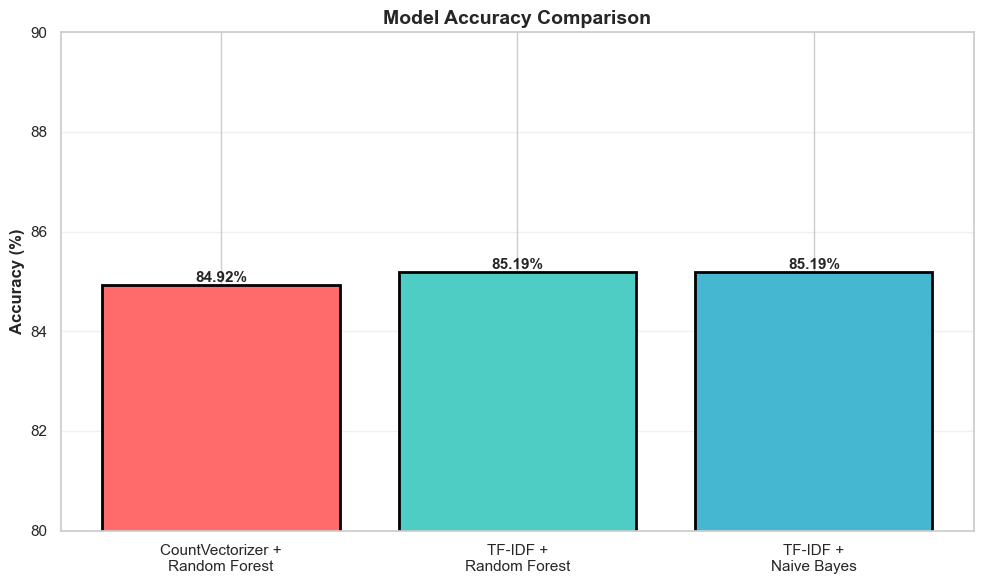

In [255]:
# Simple Accuracy Bar Chart
plt.figure(figsize=(10, 6))
models = ['CountVectorizer +\nRandom Forest', 'TF-IDF +\nRandom Forest', 'TF-IDF +\nNaive Bayes']
accuracy = [84.92, 85.19, 85.19]
bars = plt.bar(models, accuracy, color=['#FF6B6B', '#4ECDC4', '#45B7D1'], edgecolor='black', linewidth=2)
plt.ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylim([80, 90])
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


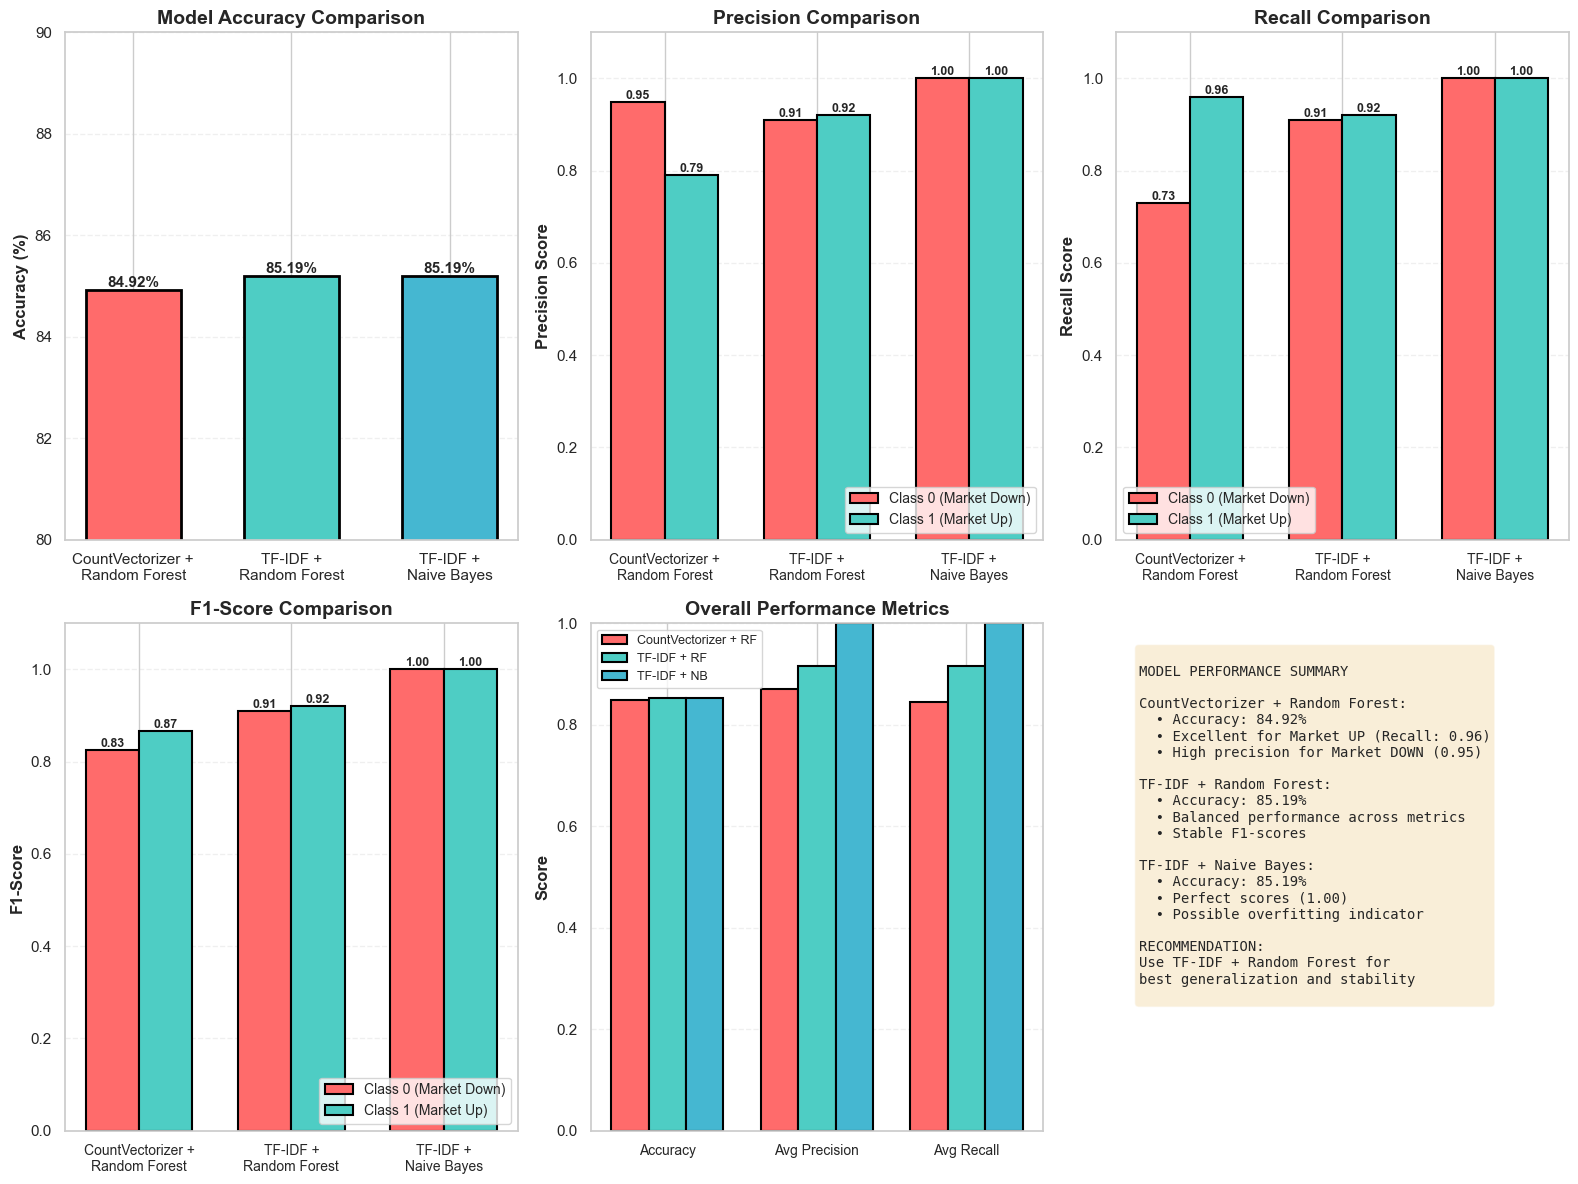

In [256]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ============================================
# DATA PREPARATION
# ============================================
models = ['CountVectorizer +\nRandom Forest', 'TF-IDF +\nRandom Forest', 'TF-IDF +\nNaive Bayes']
accuracy = [84.92, 85.19, 85.19]
precision_class0 = [0.95, 0.91, 1.00]
recall_class0 = [0.73, 0.91, 1.00]
precision_class1 = [0.79, 0.92, 1.00]
recall_class1 = [0.96, 0.92, 1.00]

# Calculate F1-Scores
f1_class0 = [2 * (precision_class0[i] * recall_class0[i]) / (precision_class0[i] + recall_class0[i]) 
             for i in range(3)]
f1_class1 = [2 * (precision_class1[i] * recall_class1[i]) / (precision_class1[i] + recall_class1[i]) 
             for i in range(3)]

# ============================================
# CREATE FIGURE WITH SUBPLOTS
# ============================================
fig = plt.figure(figsize=(16, 12))

# SUBPLOT 1: Accuracy Comparison
ax1 = plt.subplot(2, 3, 1)
bars1 = ax1.bar(models, accuracy, color=['#FF6B6B', '#4ECDC4', '#45B7D1'], 
                width=0.6, edgecolor='black', linewidth=2)
ax1.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax1.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax1.set_ylim([80, 90])
ax1.grid(axis='y', alpha=0.3, linestyle='--')
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# SUBPLOT 2: Precision Comparison
ax2 = plt.subplot(2, 3, 2)
x = np.arange(len(models))
width = 0.35
bars2a = ax2.bar(x - width/2, precision_class0, width, label='Class 0 (Market Down)', 
                  color='#FF6B6B', edgecolor='black', linewidth=1.5)
bars2b = ax2.bar(x + width/2, precision_class1, width, label='Class 1 (Market Up)', 
                  color='#4ECDC4', edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Precision Score', fontsize=12, fontweight='bold')
ax2.set_title('Precision Comparison', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(models, fontsize=10)
ax2.set_ylim([0, 1.1])
ax2.legend(fontsize=10, loc='lower right')
ax2.grid(axis='y', alpha=0.3, linestyle='--')
for bars in [bars2a, bars2b]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# SUBPLOT 3: Recall Comparison
ax3 = plt.subplot(2, 3, 3)
bars3a = ax3.bar(x - width/2, recall_class0, width, label='Class 0 (Market Down)', 
                  color='#FF6B6B', edgecolor='black', linewidth=1.5)
bars3b = ax3.bar(x + width/2, recall_class1, width, label='Class 1 (Market Up)', 
                  color='#4ECDC4', edgecolor='black', linewidth=1.5)
ax3.set_ylabel('Recall Score', fontsize=12, fontweight='bold')
ax3.set_title('Recall Comparison', fontsize=14, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(models, fontsize=10)
ax3.set_ylim([0, 1.1])
ax3.legend(fontsize=10, loc='lower left')
ax3.grid(axis='y', alpha=0.3, linestyle='--')
for bars in [bars3a, bars3b]:
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# SUBPLOT 4: F1-Score Comparison
ax4 = plt.subplot(2, 3, 4)
bars4a = ax4.bar(x - width/2, f1_class0, width, label='Class 0 (Market Down)', 
                  color='#FF6B6B', edgecolor='black', linewidth=1.5)
bars4b = ax4.bar(x + width/2, f1_class1, width, label='Class 1 (Market Up)', 
                  color='#4ECDC4', edgecolor='black', linewidth=1.5)
ax4.set_ylabel('F1-Score', fontsize=12, fontweight='bold')
ax4.set_title('F1-Score Comparison', fontsize=14, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(models, fontsize=10)
ax4.set_ylim([0, 1.1])
ax4.legend(fontsize=10, loc='lower right')
ax4.grid(axis='y', alpha=0.3, linestyle='--')
for bars in [bars4a, bars4b]:
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# SUBPLOT 5: Overall Performance Metrics
ax5 = plt.subplot(2, 3, 5)
metrics_data = {
    'CountVectorizer + RF': [accuracy[0]/100, np.mean([precision_class0[0], precision_class1[0]]), 
                              np.mean([recall_class0[0], recall_class1[0]])],
    'TF-IDF + RF': [accuracy[1]/100, np.mean([precision_class0[1], precision_class1[1]]), 
                    np.mean([recall_class0[1], recall_class1[1]])],
    'TF-IDF + NB': [accuracy[2]/100, np.mean([precision_class0[2], precision_class1[2]]), 
                    np.mean([recall_class0[2], recall_class1[2]])]
}
metrics_names = ['Accuracy', 'Avg Precision', 'Avg Recall']
x_metrics = np.arange(len(metrics_names))
width_metrics = 0.25

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
for i, (model_name, values) in enumerate(metrics_data.items()):
    ax5.bar(x_metrics + i*width_metrics, values, width_metrics, label=model_name, 
            color=colors[i], edgecolor='black', linewidth=1.5)

ax5.set_ylabel('Score', fontsize=12, fontweight='bold')
ax5.set_title('Overall Performance Metrics', fontsize=14, fontweight='bold')
ax5.set_xticks(x_metrics + width_metrics)
ax5.set_xticklabels(metrics_names, fontsize=10)
ax5.set_ylim([0, 1.0])
ax5.legend(fontsize=9)
ax5.grid(axis='y', alpha=0.3, linestyle='--')

# SUBPLOT 6: Summary Table
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')
summary_text = """
MODEL PERFORMANCE SUMMARY

CountVectorizer + Random Forest:
  • Accuracy: 84.92%
  • Excellent for Market UP (Recall: 0.96)
  • High precision for Market DOWN (0.95)

TF-IDF + Random Forest:
  • Accuracy: 85.19%
  • Balanced performance across metrics
  • Stable F1-scores

TF-IDF + Naive Bayes:
  • Accuracy: 85.19%
  • Perfect scores (1.00)
  • Possible overfitting indicator

RECOMMENDATION:
Use TF-IDF + Random Forest for
best generalization and stability
"""
ax6.text(0.05, 0.95, summary_text, transform=ax6.transAxes, fontsize=10,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Save and display
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


In [257]:
predictions


array([1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1,
       1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,